**This code use RoBERTa model for Covid19 datasets (CgatGPT-generated data, AND Falcon-generated dataset) with three main experiments:**


1.   **Experiment1**: train the model using original dataset and test it on original set
2.   **Experiment2**: train the model using synthetic dataset and test it on original set then synth set
3.   **Experiment3**: train the model using merge dataset and test it on original set




In [1]:
!pip install torch
!pip install transformers
!pip install pandas
!pip install emoji

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.5/7.5 MB 27.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 268.8/268.8 kB 26.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.8/7.8 MB 87.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 73.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 358.9/358.9 kB 5.8 MB/s eta 0:00:00


In [2]:
## Import Basics
import pandas as pd
import numpy as np
import string
import emoji
import re
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
import torch
from torch.utils.data import DataLoader, Dataset
from sklearn.utils import shuffle
from transformers import AutoTokenizer, AutoModelForSequenceClassification, AdamW
from sklearn.metrics import classification_report
from transformers import AutoTokenizer, AutoModel
from textblob import TextBlob
from sklearn.metrics import confusion_matrix
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix

In [3]:
#Select the dataset to train the model

#Experiment1:
selected_train_dataset='Real_covid19_train_tweets.csv' #original trainig set
selected_test_dataset='Real_covid19_test_283.csv'  #original testing set

#Experiment2:
#for ChatGPT data:
#selected_train_dataset='ChatGPT_synth_train_covid.csv' #ChatGPT's generated data (training set)
#selected_test_dataset='Real_covid19_test_283.csv'  #original testing set
#selected_ChatGPT_test_dataset='ChatGPT_synth_test_covid.csv'  #ChatGPT's generated data (testing set)
#for Falcon data:
###selected_train_dataset='FALCON_synth_train_covid.csv'           #Falcon's  generated data (training set)
###selected_test_dataset='Real_covid19_test_283.csv'  #original testing set
###selected_Falcon_test_dataset='FALCON_synth_test_covid.csv'            #Falcon's  generated data (testing set)

#Experiment3:
#for ChatGPT merge
#selected_train_dataset='ChatGPT_merge_covid.csv'      #ChatGPT's generated data merge with original training set
#selected_test_dataset='Real_covid19_test_283.csv'  #original testing set
#for Falcon data
#selected_train_dataset='FALCON_merge_covid.csv'          #Falcon's generated data merge with original training set
#selected_test_dataset='Real_covid19_test_283.csv'  #original testing set


For the sake of simplicity, we will present one experiment, as all other experiments follow the same steps with changes in the dataset. However, we will present the results of each experiment.

**The following presents the main steps for each experiment:**

#1. Load the datasets

In [9]:
traindf = pd.read_csv(selected_train_dataset)

In [5]:
testdf = pd.read_csv(selected_test_dataset)

In [6]:
#testdf_synth= pd.read_csv(selected_ChatGPT_test_dataset) #for Experiment2 to test on synthetic data (Falcon or ChatGPT)

In [10]:
traindf.head() # 0:Against,  1:None,  2:Favor

,tweet,label
0,Yup no thank you!!! How about a vaccine for ca...,0
1,Is it supposed to make us feel better that 3 o...,0
2,Sorry. Don’t care. Take your vaccine and shove...,0
3,@Charbros1 @piersmorgan What makes you think i...,0
4,@RepDanCrenshaw As a 20 plus year paramedic I’...,0


In [11]:
#rearrange the dataset randomly
traindf = shuffle(traindf, random_state=42)
testdf = shuffle(testdf, random_state=42)
#testdf_synth=shuffle(testdf_synth, random_state=42) for exp2

In [12]:
traindf.head()

,tweet,label
530,"it better not be mandatory here, because i'm n...",0
1174,Who will have the Pfizer Covid-19 vaccine firs...,2
168,See why half of Americans won't trust a vaccin...,0
135,"i’m sorry, i believe in science or whatever bu...",0
438,So the 'flu vaccine' has been under developmen...,0


#2. Visualizing the dataset

In [11]:
traindf['label'].value_counts()

0    535
2    535
1    535
Name: label, dtype: int64

In [12]:
testdf['label'].value_counts()

2    94
1    94
0    94
Name: label, dtype: int64

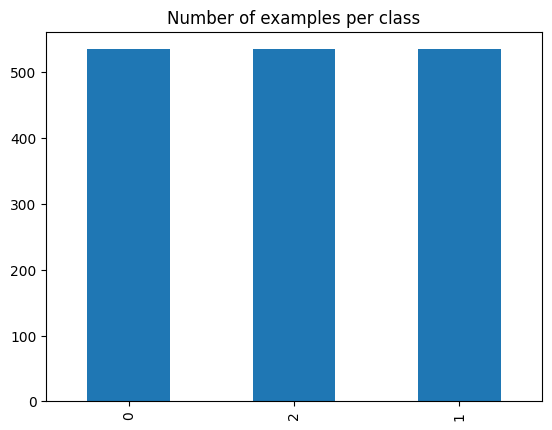

In [13]:
traindf['label'].value_counts().sort_values(ascending=False).plot(kind="bar")
plt.title("Number of examples per class");

In [14]:
traindf.shape,  testdf.shape,

((1605, 2), (282, 2))

In [19]:
# testdf_synth.shape #(for expr2)

(282, 2)

#3. Data Pre-processing

In [14]:

#clean the tweets
def preprocess(datatw):
    text = datatw.lower()  # convert to lowercase
    text = re.sub(r"http\S+|www\S+|https\S+", " ", text)  # remove URLs
    text = re.sub(r"@\w+", "<USERNAME>", text)  # normalize usernames
    text = text.translate(str.maketrans("", "", string.punctuation))  # remove punctuation
    text = emoji.demojize(text)  # remove emojis
    text = re.sub(r"(:[\w\d]+:)", "", text)  # remove emoji codes
    text = re.sub(r"\s+", " ", text).strip()  # remove extra whitespace

    return text


In [15]:
# apply preprocessing
traindf['tweet'] = traindf['tweet'].apply(preprocess)

In [16]:
traindf.head()

,tweet,label
530,it better not be mandatory here because im not...,0
1174,who will have the pfizer covid19 vaccine first...,2
168,see why half of americans wont trust a vaccine...,0
135,i’m sorry i believe in science or whatever but...,0
438,so the flu vaccine has been under development ...,0


In [17]:
testdf['tweet'] = testdf['tweet'].apply(preprocess)

In [24]:
#testdf_synth['tweet'] = testdf_synth['tweet'].apply(preprocess) #for exp2

In [18]:
#Spilt the training data using 0.11 for Merge data, 0.18 for real data to have similar size near to test set size
traindf, val_df = train_test_split(traindf[['tweet', 'label']], test_size=0.18, stratify=traindf['label'])

In [19]:
traindf.shape,  testdf.shape,

((1316, 2), (282, 2))

In [34]:
val_df.shape , #testdf_synth.shape #for exper2

((289, 2), (282, 2))

In [20]:
# creat cutom dataset to preparing tweet data for training

class Tweet_Dataset(Dataset):

  #class instance initalization (load the data)
    def __init__(self, data, tokenizer, max_length):
        self.data = data
        self.tokenizer = tokenizer
        self.max_length = max_length

    #return the length of the dataset
    def __len__(self):
        return len(self.data)

   #getting the elements
    def __getitem__(self, index):
        text = str(self.data.iloc[index]['tweet'])
        label = self.data.iloc[index]['label']
        encoding = self.tokenizer.encode_plus(
            text,
            add_special_tokens=True,
            max_length=self.max_length,
            padding='max_length',
            truncation=True,
            return_tensors='pt'
        )
       #return token IDs, attention mask for actual content, and labels
        return {
            'input_ids': encoding['input_ids'].flatten(),
            'attention_mask': encoding['attention_mask'].flatten(),
            'labels': torch.tensor(label, dtype=torch.long)
        }



#4. Train the model

In [21]:
#fine-tune RoBERTa model from hugging face
tokenizer = AutoTokenizer.from_pretrained( "cardiffnlp/twitter-roberta-large-2022-154m")
model = AutoModelForSequenceClassification.from_pretrained( "cardiffnlp/twitter-roberta-large-2022-154m", num_labels=3)


Some weights of RobertaForSequenceClassification were not initialized from the model checkpoint at cardiffnlp/twitter-roberta-large-2022-154m and are newly initialized: ['classifier.out_proj.weight', 'classifier.out_proj.bias', 'classifier.dense.bias', 'classifier.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [22]:
#max_length = 128  # the maximum sequence length for the tokens
training_dataset = Tweet_Dataset(traindf, tokenizer, 128)
test_dataset = Tweet_Dataset(testdf, tokenizer, 128)

In [23]:
#setting the data loaders, device, and optimizer for training
train_loader = DataLoader(training_dataset, batch_size=16, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=16)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model.to(device)
optim = AdamW(model.parameters(), lr= 1e-6) # best learning rate for all experemints
epochs= 7  # among (5,7,10,20) 7 is best for exp1, 5 is best for exp3 accordinf to val loss, for exp2 I avoid use validation set to use all 1000 data in the training so I follow epr3 and tried 5 epochs

/usr/local/lib/python3.10/dist-packages/transformers/optimization.py:411: FutureWarning: This implementation of AdamW is deprecated and will be removed in a future version. Use the PyTorch implementation torch.optim.AdamW instead, or set `no_deprecation_warning=True` to disable this warning
  warnings.warn(


In [24]:
# create data loader for validation set
val_dataset = Tweet_Dataset(val_df, tokenizer, 128)
val_loader = DataLoader(val_dataset, batch_size=16)


In [ ]:
# create data loader for synthetic test set for exper2
#synth_dataset = Tweet_Dataset(testdf_synth, tokenizer, 128)
#synth_loader = DataLoader(synth_dataset, batch_size=32)


In [25]:
#train the model using trainig set
model.train()
for epoch in range(epochs):
    totalloss = 0
    correctprediction=0
    total_traindata=0
    for batch in train_loader:
        optim.zero_grad()
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['labels'].to(device)

        outputs = model(input_ids, attention_mask=attention_mask, labels=labels)
        loss = outputs.loss
        totalloss += loss.item()
        total_traindata+= labels.size(0)

        loss.backward()
        optim.step()
        #calculate predicted labels
        predicted_labels = outputs.logits.argmax(dim=1)
        correctprediction += (predicted_labels == labels).sum().item()

    average_loss = totalloss / len(train_loader)
    accuracy = correctprediction / total_traindata
    print(f'Epoch {epoch+1}/{epochs} - Average Loss: {average_loss:.4f} - Accuracy: {accuracy:.4f}')


    # Validation set
    valloss = 0
    valcorrectprediction = 0
    total_valdata = 0

    model.eval()

    with torch.no_grad():
        for val_batch in val_loader:
            val_input_ids = val_batch['input_ids'].to(device)
            val_attention_mask = val_batch['attention_mask'].to(device)
            val_labels = val_batch['labels'].to(device)

            val_outputs = model(val_input_ids, attention_mask=val_attention_mask, labels=val_labels)
            valloss += val_outputs.loss.item()
            total_valdata += val_labels.size(0)

            val_predicted_labels = val_outputs.logits.argmax(dim=1)
            valcorrectprediction += (val_predicted_labels == val_labels).sum().item()
    #calculate average val loss and accuracy
    val_average_loss = valloss / len(val_loader)
    val_accuracy = valcorrectprediction / total_valdata

    print(f'Epoch {epoch+1}/{epochs} - Train Loss: {average_loss:.4f} - Train Accuracy: {accuracy:.4f} - Val Loss: {val_average_loss:.4f} - Val Accuracy: {val_accuracy:.4f}')


Epoch 1/7 - Average Loss: 1.1308 - Accuracy: 0.3427
Epoch 1/7 - Train Loss: 1.1308 - Train Accuracy: 0.3427 - Val Loss: 1.0928 - Val Accuracy: 0.3322
Epoch 2/7 - Average Loss: 0.9937 - Accuracy: 0.5357
Epoch 2/7 - Train Loss: 0.9937 - Train Accuracy: 0.5357 - Val Loss: 0.8503 - Val Accuracy: 0.6886
Epoch 3/7 - Average Loss: 0.6930 - Accuracy: 0.7454
Epoch 3/7 - Train Loss: 0.6930 - Train Accuracy: 0.7454 - Val Loss: 0.6291 - Val Accuracy: 0.7509
Epoch 4/7 - Average Loss: 0.4687 - Accuracy: 0.8381
Epoch 4/7 - Train Loss: 0.4687 - Train Accuracy: 0.8381 - Val Loss: 0.4882 - Val Accuracy: 0.7785
Epoch 5/7 - Average Loss: 0.3296 - Accuracy: 0.8830
Epoch 5/7 - Train Loss: 0.3296 - Train Accuracy: 0.8830 - Val Loss: 0.4490 - Val Accuracy: 0.8062
Epoch 6/7 - Average Loss: 0.2279 - Accuracy: 0.9248
Epoch 6/7 - Train Loss: 0.2279 - Train Accuracy: 0.9248 - Val Loss: 0.4463 - Val Accuracy: 0.8062
Epoch 7/7 - Average Loss: 0.1554 - Accuracy: 0.9544
Epoch 7/7 - Train Loss: 0.1554 - Train Accuracy:

#5. Test the model on the test set

**the following present the test results for each experiment:**

## Experemint1 results: Original data result on original test


In [27]:
# Test the model performance that trained using the original data on the original test set

model.eval()
totalcorrect = 0
totaldata = 0
predicted_labelslist = []
true_labelslist = []
with torch.no_grad():
    for batch in test_loader:
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['labels'].to(device)

        outputs = model(input_ids=input_ids, attention_mask=attention_mask)
        predicted_labels = torch.argmax(outputs.logits, dim=1)

        totalcorrect += (predicted_labels == labels).sum().item()
        totaldata += labels.size(0)
        predicted_labelslist.extend(predicted_labels.cpu().numpy())
        true_labelslist.extend(labels.cpu().numpy())

#print results
classification_rep = classification_report(true_labelslist, predicted_labelslist)
test_confusion_matrix = confusion_matrix(true_labelslist, predicted_labelslist)
print("Classification Report:")
print(classification_rep)
print("Test Confusion Matrix:")
print(test_confusion_matrix)


Classification Report:
              precision    recall  f1-score   support

           0       0.82      0.87      0.85        94
           1       0.84      0.86      0.85        94
           2       0.85      0.78      0.81        94

    accuracy                           0.84       282
   macro avg       0.84      0.84      0.84       282
weighted avg       0.84      0.84      0.84       282

Test Confusion Matrix:
[[82  6  6]
 [ 6 81  7]
 [12  9 73]]


In [28]:
# Test the model performance that trained using the original data on the original val set

model.eval()
totalcorrect = 0
totaldata = 0
predicted_labelslist = []
true_labelslist = []
with torch.no_grad():
    for batch in val_loader:
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['labels'].to(device)

        outputs = model(input_ids=input_ids, attention_mask=attention_mask)
        predicted_labels = torch.argmax(outputs.logits, dim=1)

        totalcorrect += (predicted_labels == labels).sum().item()
        totaldata += labels.size(0)
        predicted_labelslist.extend(predicted_labels.cpu().numpy())
        true_labelslist.extend(labels.cpu().numpy())

#print results
classification_rep = classification_report(true_labelslist, predicted_labelslist)
test_confusion_matrix = confusion_matrix(true_labelslist, predicted_labelslist)
print("Classification Report:")
print(classification_rep)
print("Test Confusion Matrix:")
print(test_confusion_matrix)


Classification Report:
              precision    recall  f1-score   support

           0       0.85      0.85      0.85        96
           1       0.83      0.82      0.83        97
           2       0.80      0.81      0.81        96

    accuracy                           0.83       289
   macro avg       0.83      0.83      0.83       289
weighted avg       0.83      0.83      0.83       289

Test Confusion Matrix:
[[82  8  6]
 [ 4 80 13]
 [10  8 78]]


##Experemint2,3 for ChatGPT's synthetic data

### Experemint2 results: Synthetic data results on original and Synthetic test sets


In [ ]:
# Test the model performance that trained using the synthetic on the original test set

model.eval()
totalcorrect = 0
totaldata = 0
predicted_labelslist = []
true_labelslist = []
with torch.no_grad():
    for batch in test_loader:
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['labels'].to(device)

        outputs = model(input_ids=input_ids, attention_mask=attention_mask)
        predicted_labels = torch.argmax(outputs.logits, dim=1)

        totalcorrect += (predicted_labels == labels).sum().item()
        totaldata += labels.size(0)
        predicted_labelslist.extend(predicted_labels.cpu().numpy())
        true_labelslist.extend(labels.cpu().numpy())

#print results
classification_rep = classification_report(true_labelslist, predicted_labelslist)
test_confusion_matrix = confusion_matrix(true_labelslist, predicted_labelslist)
print("Classification Report:")
print(classification_rep)
print("Test Confusion Matrix:")
print(test_confusion_matrix)

Classification Report:
              precision    recall  f1-score   support

           0       0.62      0.87      0.72        94
           1       0.74      0.74      0.74        94
           2       0.69      0.39      0.50        94

    accuracy                           0.67       282
   macro avg       0.68      0.67      0.65       282
weighted avg       0.68      0.67      0.65       282

Test Confusion Matrix:
[[82  4  8]
 [15 70  9]
 [36 21 37]]


In [ ]:
# Test the model performance that trained using the synthetic on the synthetic test set

model.eval()
totalcorrect = 0
totaldata = 0
predicted_labelslist = []
true_labelslist = []
with torch.no_grad():
    for batch in synth_loader:
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['labels'].to(device)

        outputs = model(input_ids=input_ids, attention_mask=attention_mask)
        predicted_labels = torch.argmax(outputs.logits, dim=1)

        totalcorrect += (predicted_labels == labels).sum().item()
        totaldata += labels.size(0)
        predicted_labelslist.extend(predicted_labels.cpu().numpy())
        true_labelslist.extend(labels.cpu().numpy())

#print results
classification_rep = classification_report(true_labelslist, predicted_labelslist)
test_confusion_matrix = confusion_matrix(true_labelslist, predicted_labelslist)
print("Classification Report:")
print(classification_rep)
print("Test Confusion Matrix:")
print(test_confusion_matrix)

Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.99      0.99        94
           1       0.99      1.00      0.99        94
           2       0.99      0.99      0.99        94

    accuracy                           0.99       282
   macro avg       0.99      0.99      0.99       282
weighted avg       0.99      0.99      0.99       282

Test Confusion Matrix:
[[93  0  1]
 [ 0 94  0]
 [ 0  1 93]]


### Experemint3 results: Merge data results on original

In [ ]:
# Test the model performance that trained using the original data on the original val set

model.eval()
totalcorrect = 0
totaldata = 0
predicted_labelslist = []
true_labelslist = []
with torch.no_grad():
    for batch in val_loader:
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['labels'].to(device)

        outputs = model(input_ids=input_ids, attention_mask=attention_mask)
        predicted_labels = torch.argmax(outputs.logits, dim=1)

        totalcorrect += (predicted_labels == labels).sum().item()
        totaldata += labels.size(0)
        predicted_labelslist.extend(predicted_labels.cpu().numpy())
        true_labelslist.extend(labels.cpu().numpy())

#print results
classification_rep = classification_report(true_labelslist, predicted_labelslist)
test_confusion_matrix = confusion_matrix(true_labelslist, predicted_labelslist)
print("Classification Report:")
print(classification_rep)
print("Test Confusion Matrix:")
print(test_confusion_matrix)


Classification Report:
              precision    recall  f1-score   support

           0       0.93      0.95      0.94        96
           1       0.88      0.91      0.89        95
           2       0.89      0.84      0.87        96

    accuracy                           0.90       287
   macro avg       0.90      0.90      0.90       287
weighted avg       0.90      0.90      0.90       287

Test Confusion Matrix:
[[91  1  4]
 [ 3 86  6]
 [ 4 11 81]]


In [ ]:
# Test the model performance that trained using the original data on the original test set

model.eval()
totalcorrect = 0
totaldata = 0
predicted_labelslist = []
true_labelslist = []
with torch.no_grad():
    for batch in test_loader:
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['labels'].to(device)

        outputs = model(input_ids=input_ids, attention_mask=attention_mask)
        predicted_labels = torch.argmax(outputs.logits, dim=1)

        totalcorrect += (predicted_labels == labels).sum().item()
        totaldata += labels.size(0)
        predicted_labelslist.extend(predicted_labels.cpu().numpy())
        true_labelslist.extend(labels.cpu().numpy())

#print results
classification_rep = classification_report(true_labelslist, predicted_labelslist)
test_confusion_matrix = confusion_matrix(true_labelslist, predicted_labelslist)
print("Classification Report:")
print(classification_rep)
print("Test Confusion Matrix:")
print(test_confusion_matrix)

Classification Report:
              precision    recall  f1-score   support

           0       0.90      0.81      0.85        94
           1       0.74      0.93      0.82        94
           2       0.84      0.72      0.78        94

    accuracy                           0.82       282
   macro avg       0.83      0.82      0.82       282
weighted avg       0.83      0.82      0.82       282

Test Confusion Matrix:
[[76 11  7]
 [ 1 87  6]
 [ 7 19 68]]


##Experemint 2,3 for Falcon's synthetic data

### Experemint2 results: Synthetic data results on original and Synthetic test sets


In [ ]:
# Test the model performance that trained using the synthetic on the original test set

model.eval()
totalcorrect = 0
totaldata = 0
predicted_labelslist = []
true_labelslist = []
with torch.no_grad():
    for batch in test_loader:
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['labels'].to(device)

        outputs = model(input_ids=input_ids, attention_mask=attention_mask)
        predicted_labels = torch.argmax(outputs.logits, dim=1)

        totalcorrect += (predicted_labels == labels).sum().item()
        totaldata += labels.size(0)
        predicted_labelslist.extend(predicted_labels.cpu().numpy())
        true_labelslist.extend(labels.cpu().numpy())

#print results
classification_rep = classification_report(true_labelslist, predicted_labelslist)
test_confusion_matrix = confusion_matrix(true_labelslist, predicted_labelslist)
print("Classification Report:")
print(classification_rep)
print("Test Confusion Matrix:")
print(test_confusion_matrix)

Classification Report:
              precision    recall  f1-score   support

           0       0.67      0.87      0.76        94
           1       0.62      0.74      0.68        94
           2       0.66      0.33      0.44        94

    accuracy                           0.65       282
   macro avg       0.65      0.65      0.63       282
weighted avg       0.65      0.65      0.63       282

Test Confusion Matrix:
[[82  6  6]
 [14 70 10]
 [27 36 31]]


In [ ]:
# Test the model performance that trained using the synthetic on the synthetic test set

model.eval()
totalcorrect = 0
totaldata = 0
predicted_labelslist = []
true_labelslist = []
with torch.no_grad():
    for batch in synth_loader:
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['labels'].to(device)

        outputs = model(input_ids=input_ids, attention_mask=attention_mask)
        predicted_labels = torch.argmax(outputs.logits, dim=1)

        totalcorrect += (predicted_labels == labels).sum().item()
        totaldata += labels.size(0)
        predicted_labelslist.extend(predicted_labels.cpu().numpy())
        true_labelslist.extend(labels.cpu().numpy())

#print results
classification_rep = classification_report(true_labelslist, predicted_labelslist)
test_confusion_matrix = confusion_matrix(true_labelslist, predicted_labelslist)
print("Classification Report:")
print(classification_rep)
print("Test Confusion Matrix:")
print(test_confusion_matrix)

Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.99      0.99        94
           1       1.00      0.98      0.99        94
           2       0.97      1.00      0.98        94

    accuracy                           0.99       282
   macro avg       0.99      0.99      0.99       282
weighted avg       0.99      0.99      0.99       282

Test Confusion Matrix:
[[93  0  1]
 [ 0 92  2]
 [ 0  0 94]]


###Experemint3 results: Merge data results on original

In [ ]:
# Test the model performance that trained using the original data on the original val set

model.eval()
totalcorrect = 0
totaldata = 0
predicted_labelslist = []
true_labelslist = []
with torch.no_grad():
    for batch in val_loader:
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['labels'].to(device)

        outputs = model(input_ids=input_ids, attention_mask=attention_mask)
        predicted_labels = torch.argmax(outputs.logits, dim=1)

        totalcorrect += (predicted_labels == labels).sum().item()
        totaldata += labels.size(0)
        predicted_labelslist.extend(predicted_labels.cpu().numpy())
        true_labelslist.extend(labels.cpu().numpy())

#print results
classification_rep = classification_report(true_labelslist, predicted_labelslist)
test_confusion_matrix = confusion_matrix(true_labelslist, predicted_labelslist)
print("Classification Report:")
print(classification_rep)
print("Test Confusion Matrix:")
print(test_confusion_matrix)


Classification Report:
              precision    recall  f1-score   support

           0       0.91      0.87      0.89        95
           1       0.88      0.93      0.90        96
           2       0.88      0.88      0.88        96

    accuracy                           0.89       287
   macro avg       0.89      0.89      0.89       287
weighted avg       0.89      0.89      0.89       287

Test Confusion Matrix:
[[83  7  5]
 [ 1 89  6]
 [ 7  5 84]]


In [ ]:
# Test the model performance that trained using the original data on the original test set

model.eval()
totalcorrect = 0
totaldata = 0
predicted_labelslist = []
true_labelslist = []
with torch.no_grad():
    for batch in test_loader:
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['labels'].to(device)

        outputs = model(input_ids=input_ids, attention_mask=attention_mask)
        predicted_labels = torch.argmax(outputs.logits, dim=1)

        totalcorrect += (predicted_labels == labels).sum().item()
        totaldata += labels.size(0)
        predicted_labelslist.extend(predicted_labels.cpu().numpy())
        true_labelslist.extend(labels.cpu().numpy())

#print results
classification_rep = classification_report(true_labelslist, predicted_labelslist)
test_confusion_matrix = confusion_matrix(true_labelslist, predicted_labelslist)
print("Classification Report:")
print(classification_rep)
print("Test Confusion Matrix:")
print(test_confusion_matrix)

Classification Report:
              precision    recall  f1-score   support

           0       0.81      0.84      0.82        94
           1       0.78      0.88      0.83        94
           2       0.84      0.69      0.76        94

    accuracy                           0.80       282
   macro avg       0.81      0.80      0.80       282
weighted avg       0.81      0.80      0.80       282

Test Confusion Matrix:
[[79 10  5]
 [ 4 83  7]
 [15 14 65]]
